<a href="https://colab.research.google.com/github/Solu-victoria/SS-DLI-Research/blob/main/Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
email = userdata.get('gb_email')
name = userdata.get('gb_name')
secret_key = userdata.get('gb_secret_key')

In [2]:
!git clone https://{secret_key}@github.com/Solu-victoria/SS-DLI-Research.git

Cloning into 'SS-DLI-Research'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 50 (delta 17), reused 20 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 17.17 KiB | 4.29 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:
!git config --global user.email {email}
!git config --global user.name {name}

In [3]:
%cd SS-DLI-Research/

/content/SS-DLI-Research


In [9]:
!git add .

In [10]:
!git commit -m 'model train'

[main ce81668] model train
 13 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 models/baseline/run_1.pth
 create mode 100644 models/baseline/run_2.pth
 create mode 100644 models/baseline/run_3.pth
 create mode 100644 models/baseline/run_4.pth
 create mode 100644 models/baseline/run_5.pth
 create mode 100644 models/multi/run_1.pth
 create mode 100644 models/multi/run_2.pth
 create mode 100644 models/multi/run_3.pth
 create mode 100644 models/multi/run_4.pth
 create mode 100644 models/multi/run_5.pth


In [11]:
!git push

Enumerating objects: 22, done.
Counting objects: 100% (22/22), done.
Delta compression using up to 2 threads
Compressing objects: 100% (19/19), done.
Writing objects: 100% (19/19), 189.40 KiB | 8.61 MiB/s, done.
Total 19 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Solu-victoria/SS-DLI-Research.git
   49a03ef..ce81668  main -> main


In [12]:
!git pull

Already up to date.


## EXPERIMENT 1 — Learning Curve Comparison

In [5]:
from train import run_train_experiment
import numpy as np
import matplotlib.pyplot as plt

In [6]:
baseline_runs, multi_runs = run_train_experiment(num_runs=5, episodes=200)


Run 1/5


/content/SS-DLI-Research/agent.py:51: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states)


Baseline | Episode 0 | Reward: 28.48
Baseline | Episode 1 | Reward: 33.71
Baseline | Episode 2 | Reward: 46.15
Baseline | Episode 3 | Reward: 26.94
Baseline | Episode 4 | Reward: 25.58
Baseline | Episode 5 | Reward: 29.25
Baseline | Episode 6 | Reward: 38.77
Baseline | Episode 7 | Reward: 39.34
Baseline | Episode 8 | Reward: 26.98
Baseline | Episode 9 | Reward: 46.35
Baseline | Episode 10 | Reward: 49.70
Baseline | Episode 11 | Reward: 58.61
Baseline | Episode 12 | Reward: 65.88
Baseline | Episode 13 | Reward: 67.26
Baseline | Episode 14 | Reward: 50.25
Baseline | Episode 15 | Reward: 60.00
Baseline | Episode 16 | Reward: 67.63
Baseline | Episode 17 | Reward: 80.04
Baseline | Episode 18 | Reward: 58.50
Baseline | Episode 19 | Reward: 64.99
Baseline | Episode 20 | Reward: 81.41
Baseline | Episode 21 | Reward: 68.06
Baseline | Episode 22 | Reward: 68.32
Baseline | Episode 23 | Reward: 79.98
Baseline | Episode 24 | Reward: 72.06
Baseline | Episode 25 | Reward: 69.91
Baseline | Episode 26 

In [7]:
baseline_mean = baseline_runs.mean(axis=0)
baseline_std = baseline_runs.std(axis=0)

multi_mean = multi_runs.mean(axis=0)
multi_std = multi_runs.std(axis=0)

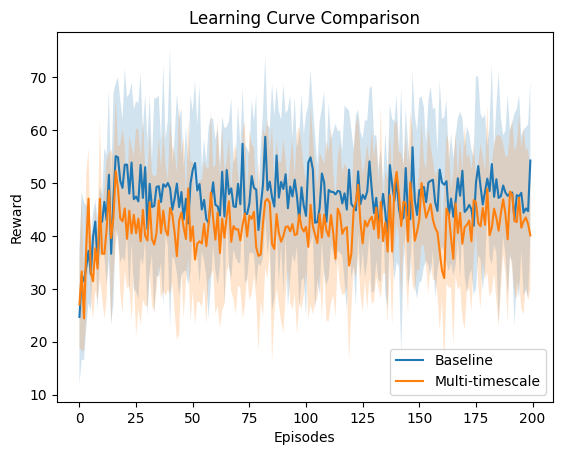

In [8]:
plt.figure()

plt.plot(baseline_mean, label="Baseline")
plt.fill_between(
    range(len(baseline_mean)),
    baseline_mean - baseline_std,
    baseline_mean + baseline_std,
    alpha=0.2
)

plt.plot(multi_mean, label="Multi-timescale")
plt.fill_between(
    range(len(multi_mean)),
    multi_mean - multi_std,
    multi_mean + multi_std,
    alpha=0.2
)

plt.legend()
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curve Comparison")

plt.show()